
#### 머신러닝의 7과정
1. 문제 정의
2. 데이터 수집(File, Survey, Database, IoT Sensor)
3. 데이터 전처리
   - 결측치, 이상치, 특성공학(Scaling, Encoding, Binning, Transform)
4. 탐색적 데이터 분석
   - 기술통계량, 시각화
5. Model선택, Hyper Parameter 조정
6. Model 학습(fit)
7. Model 평가(Evaluate)


## 문제 정의
500명의 키, 몸무게, 성별을 Feature로 한 비만도 label을 분류하는 모델 만들기!

## 데이터 수집

In [1]:
import pandas as pd

tbl = pd.read_csv('./data/bmi_500.csv', index_col='Label')
tbl

,Gender,Height,Weight
Label,,,
Obesity,Male,174,96
Normal,Male,189,87
Obesity,Female,185,110
Overweight,Female,195,104
Overweight,Male,149,61
...,...,...,...
Extreme Obesity,Female,150,153
Obesity,Female,184,121
Extreme Obesity,Female,141,136


## 데이터 전처리 및 EDA

데이터 전처리는 학습용으로 필요 없으므로 EDA 진행

In [2]:
tbl['Height'].value_counts()

Height
188    15
179    14
187    14
178    13
168    13
182    12
184    12
172    12
185    11
181    11
150    11
183    11
165    10
195    10
157    10
153    10
154    10
169    10
167     9
145     9
161     9
166     9
164     9
177     9
146     9
142     9
159     9
190     9
162     9
186     9
141     8
152     8
151     8
140     8
171     8
180     8
163     8
174     8
191     7
147     7
176     7
197     7
160     7
192     6
155     6
196     6
156     6
170     6
158     5
144     5
189     5
149     5
148     5
198     5
193     5
194     5
175     4
173     4
143     3
199     3
Name: count, dtype: int64

In [3]:
tbl['Gender'].value_counts()

Gender
Female    255
Male      245
Name: count, dtype: int64

In [4]:
tbl.describe()

,Height,Weight
count,500.000000,500.000000
mean,169.944000,106.000000
std,16.375261,32.382607
min,140.000000,50.000000
25%,156.000000,80.000000
50%,170.500000,106.000000
75%,184.000000,136.000000
max,199.000000,160.000000


In [5]:
tbl.describe(include='all')

,Gender,Height,Weight
count,500,500.000000,500.000000
unique,2,NaN,NaN
top,Female,NaN,NaN
freq,255,NaN,NaN
mean,NaN,169.944000,106.000000
std,NaN,16.375261,32.382607
min,NaN,140.000000,50.000000
25%,NaN,156.000000,80.000000
50%,NaN,170.500000,106.000000
75%,NaN,184.000000,136.000000


In [6]:
# 예측 라벨(y)
tbl.index.unique()

Index(['Obesity', 'Normal', 'Overweight', 'Extreme Obesity', 'Weak',
       'Extremely Weak'],
      dtype='object', name='Label')

In [7]:
tbl.index.value_counts()

Label
Extreme Obesity    198
Obesity            130
Normal              69
Overweight          68
Weak                22
Extremely Weak      13
Name: count, dtype: int64

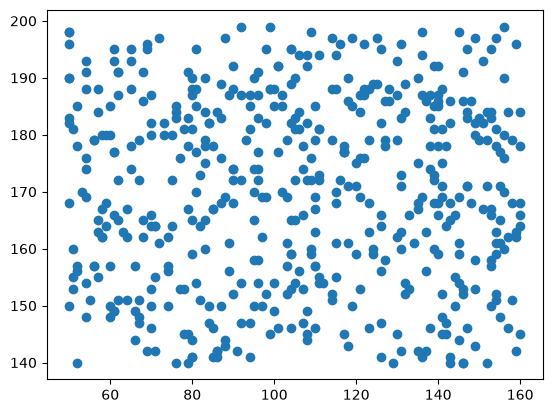

In [8]:
import matplotlib.pyplot as plt

# 데이터의 분포를 살펴보기 위해 산점도 그래프 분석
plt.scatter(tbl['Weight'], #x축
           tbl['Height']   #y축
           )
plt.show()

In [9]:
def myScatter(class_name, color) : # 매개변수로는 정답과 색깔
    tmp = tbl.loc[class_name] # 매개변수로 받아준 class_name데이터만

    plt.scatter(tmp['Weight'],
                tmp['Height'],
                c = color,          # 매개변수로 받은 색깔로 색상 설정
                label = class_name  # 범례 출력시 텍스트 설정
               )

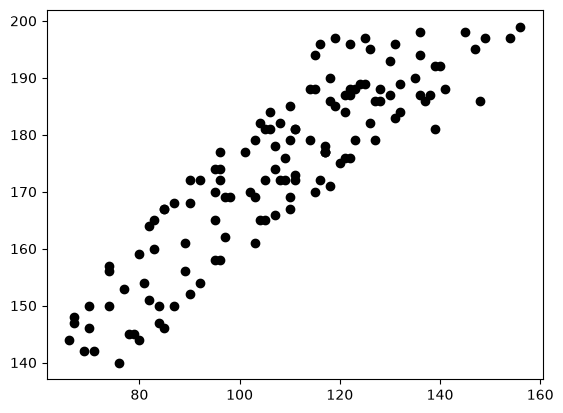

In [10]:
myScatter('Obesity','black')

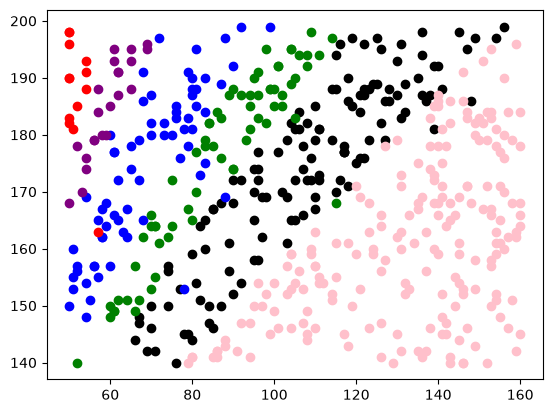

In [11]:
myScatter('Obesity', 'black')
myScatter('Normal', 'blue')
myScatter('Overweight', 'green')
myScatter('Extreme Obesity', 'pink')
myScatter('Weak', 'purple')
myScatter('Extremely Weak', 'red')

## 모델링(모델선택, 학습, 평가)
- 1. 문제와 정답 분리
  2. train, test셋으로 분리
  3. 모델 생성
  4. 학습 및 평가
  5. 하이퍼파라미터 조정 평가

In [12]:
data = pd.read_csv('./data/bmi_500.csv')
data

,Gender,Height,Weight,Label
0,Male,174,96,Obesity
1,Male,189,87,Normal
2,Female,185,110,Obesity
3,Female,195,104,Overweight
4,Male,149,61,Overweight
...,...,...,...,...
495,Female,150,153,Extreme Obesity
496,Female,184,121,Obesity
497,Female,141,136,Extreme Obesity
498,Male,150,95,Extreme Obesity


In [13]:
# 특성(X) 정답(y) 분리
X = data.loc[:, 'Height':'Weight']
y = data.loc[:, 'Label']

In [14]:
X

,Height,Weight
0,174,96
1,189,87
2,185,110
3,195,104
4,149,61
...,...,...
495,150,153
496,184,121
497,141,136
498,150,95


In [15]:
y

0              Obesity
1               Normal
2              Obesity
3           Overweight
4           Overweight
            ...       
495    Extreme Obesity
496            Obesity
497    Extreme Obesity
498    Extreme Obesity
499    Extreme Obesity
Name: Label, Length: 500, dtype: object

In [16]:
print(X.shape)
print(y.shape)

(500, 2)
(500,)


In [17]:
# train : test = 7 : 3 비율로 나누기
# label이 섞여 있어 index로 단순히 나눠도 문제 없음

X_train = data.iloc[:350, 1:3]
y_train = data.iloc[:350, 3]
X_test = data.iloc[350:, 1:3]
y_test = data.iloc[350:, 3]

In [18]:
from sklearn.neighbors import KNeighborsClassifier

# n_neighbors 값은 전체 학습데이터수의 제곱근 값으로 먼저 기준을 잡기
knn = KNeighborsClassifier(n_neighbors = 18)

In [21]:
print(knn.fit(X_train,y_train))

KNeighborsClassifier(n_neighbors=18)


In [22]:
pred = knn.predict(X_test)
pred

array(['Normal', 'Normal', 'Normal', 'Extreme Obesity', 'Extremely Weak',
       'Obesity', 'Obesity', 'Extreme Obesity', 'Normal',
       'Extreme Obesity', 'Weak', 'Extreme Obesity', 'Extreme Obesity',
       'Extreme Obesity', 'Extreme Obesity', 'Obesity', 'Overweight',
       'Obesity', 'Extreme Obesity', 'Obesity', 'Overweight',
       'Extreme Obesity', 'Weak', 'Normal', 'Obesity', 'Extreme Obesity',
       'Extreme Obesity', 'Extreme Obesity', 'Extreme Obesity',
       'Overweight', 'Extreme Obesity', 'Weak', 'Obesity',
       'Extreme Obesity', 'Extreme Obesity', 'Normal', 'Extreme Obesity',
       'Obesity', 'Overweight', 'Normal', 'Normal', 'Normal', 'Normal',
       'Overweight', 'Extreme Obesity', 'Overweight', 'Overweight',
       'Extreme Obesity', 'Normal', 'Extreme Obesity', 'Overweight',
       'Obesity', 'Normal', 'Obesity', 'Obesity', 'Extreme Obesity',
       'Normal', 'Extreme Obesity', 'Extreme Obesity', 'Extreme Obesity',
       'Normal', 'Obesity', 'Extreme Obes

In [ ]:
from sklearn import metrics

metrics.accuracy_score(y_test,pred)

0.94

In [ ]:
knn.score(X_test, y_test)

0.94

In [ ]:
from sklearn.metrics import classification_report
pred = knn.predict(X_test)
print(classification_report(pred, y_test))

# precision : 정밀도(모델기준), 모델이 *이라고 예측한 것 중에서, 실제로도 데이터가 *인 비율
# recall : 재현율(데이터 기준), 실제 *데이터 중에서, 모델이 *라고 예측한 비율
# f1-score : Precision과 Recall의 조화 평균 : (precision * recall) / (precision + recall) *2
# support : 데이터의 개수

                 precision    recall  f1-score   support

Extreme Obesity       0.98      0.93      0.95        67
 Extremely Weak       1.00      1.00      1.00         3
         Normal       0.96      0.75      0.84        32
        Obesity       0.86      0.94      0.90        32
     Overweight       0.85      0.92      0.88        12
           Weak       0.36      1.00      0.53         4

       accuracy                           0.89       150
      macro avg       0.84      0.92      0.85       150
   weighted avg       0.92      0.89      0.90       150



In [ ]:
# 다른 값을 입력 했을 때의 분류 결과 확인하기
knn.predict([[165,85]])

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['Obesity'], dtype=object)

## Iris 데이터 꽃 품종 분류

## 문제정의(목표)

- KNN 모델(K - Nearest Neighbors) : 유유상종의 개념과 비슷
    - 새로운 데이터가 들어왔을 때 거리계산을 통해서 가장 가까운 특성의 데이터로 예측하는 모델
- KNN 모델의 이웃의 숫자를 조정해보자(n_neighbors 개수를 조정, 하이퍼 파라미터 튜닝) - 일반화가 이루어지는 방향으로 조정
- 붓꽃 데이터를 활용
    - 특성 4개 : 꽃잎의 길이, 꽃잎의 너비, 꽃받침의 길이, 꽃받침의 너비
    - 정답 : 클래스 3개 - 붓꽃의 3가지 품종 (setosa, versicolor, virginica)
- 목표 : 특성 4개를 통해 붓꽃의 품종을 예측하는 모델

## 데이터 수집

scikit learn의 iris 데이터

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()
iris

# data : 문제 데이터
# target : 정답 데이터
# target_names : 정답데이터 명
# feature_names : 컬럼명
# DESCR : 데이터셋에 대한 설명

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

## 데이터 전처리

학습용 데이터로 전처리 불필요

## EDA

In [ ]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
iris.values()

dict_values([array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
 

In [ ]:
iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
iris.describe() # dataframe에 대해 설명하는 역할로 iris는 dict 형태로 describe

AttributeError: describe

In [ ]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
iris['data'].shape

(150, 4)

In [ ]:
iris['target'].shape

(150,)

In [ ]:
iris_df = pd.DataFrame(iris['data'], columns = iris['feature_names'])
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
iris['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
X = iris_df
y = iris['target']

### train_test_split / random_state
그냥 index 기준으로 나눈다면 label 중 '2'만 test에 들어가는 과대적합(Overfitting) 위험이 있어 random하게 섞는다

random_state = 8로 설정하면 계속 유지하여 같은 상황에서 같은 데이터를 통해 모델끼리 서로 비교하도록 한다

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# train_test_split() : 알아서 훈련용과 테스트용 데이터루 나누어주는 도구(랜덤 샘플링)
# train_test_split(문제, 정답, 평가데이터의 비율, 랜덤시드값)

# X_train, X_test, y_train, y_test 순서 중요
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                   random_state = 8
                                                   )

X_train    # index가 달라짐

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
49,5.0,3.3,1.4,0.2
43,5.0,3.5,1.6,0.6
40,5.0,3.5,1.3,0.3
139,6.9,3.1,5.4,2.1
111,6.4,2.7,5.3,1.9
...,...,...,...,...
83,6.0,2.7,5.1,1.6
136,6.3,3.4,5.6,2.4
133,6.3,2.8,5.1,1.5
105,7.6,3.0,6.6,2.1


In [ ]:
y_train

array([0, 0, 0, 2, 2, 2, 2, 0, 0, 1, 1, 1, 0, 0, 1, 2, 0, 1, 2, 1, 0, 2,
       1, 1, 0, 1, 2, 2, 0, 2, 2, 1, 1, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2,
       0, 2, 0, 0, 2, 0, 1, 0, 0, 1, 0, 2, 1, 0, 0, 0, 0, 1, 1, 2, 1, 1,
       0, 2, 1, 2, 2, 2, 2, 1, 0, 2, 0, 2, 1, 2, 1, 1, 1, 0, 2, 2, 0, 0,
       1, 1, 1, 1, 0, 2, 2, 1, 1, 2, 0, 2, 1, 2, 2, 2, 1])

#### 산점도 매트릭스로 시각화 해보기
- x축과 y축에 특성을 넣고 출력하는 산점도를 여러개 한번에 출력시켜줌
- 여러 특성쌍의 관계를 동시에 확인할 수 있음
- 특성의 개수가 너무 많다면 확인하기 힘들어짐

array([[<Axes: xlabel='sepal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='sepal width (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='sepal width (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal length (cm)', ylabel='petal length (cm)'>,
        <Axes: xlabel='petal width (cm)', ylabel='petal length (cm)'>],
       [<Axes: xlabel='sepal length (cm)', ylabel='petal width (cm)'>,
        <Axes: xlabel='sepal width (cm)', ylabel='petal width (cm)'>,
  

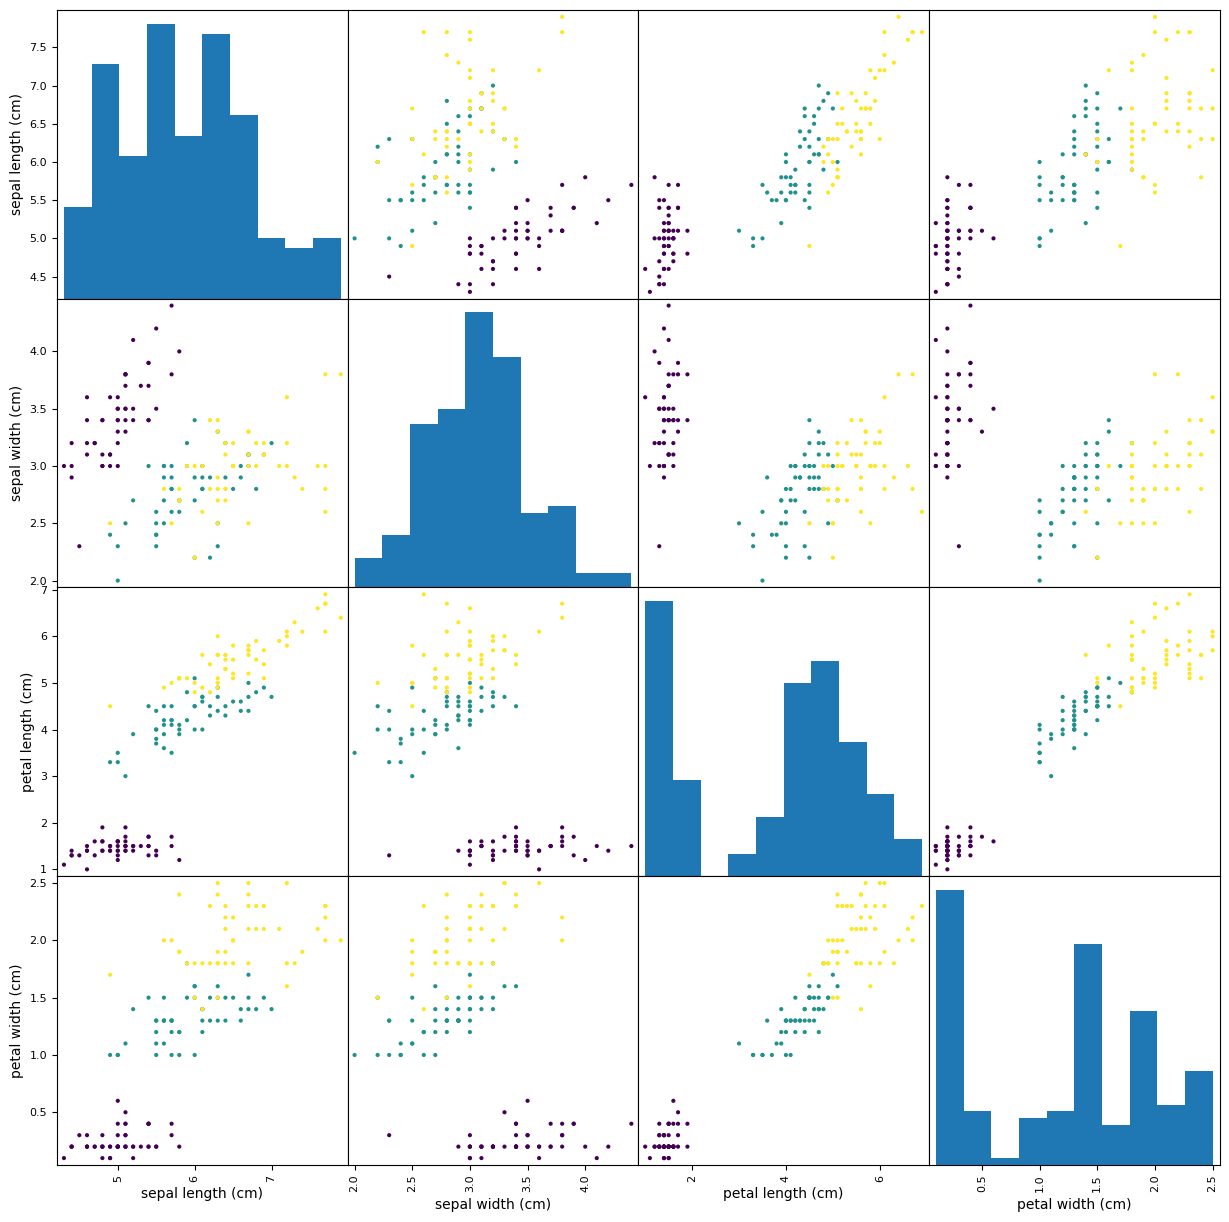

In [ ]:
# 서로 다른 두 Feature 들 사이의 상관관계를 직관적으로 명시적으로 살피기 위한 작업
pd.plotting.scatter_matrix(iris_df,
                          figsize=(15,15),
                           c = y,   # 데이터 색상
                           alpha = 1  # matrix 불투명도
                          )

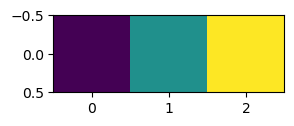

In [ ]:
import numpy as np
# 어떤 색이 어떤 label을 지니는지 표현을 보려고
plt.figure(figsize=(4,1))
# iris['target']
plt.imshow([np.unique(iris['target'])])

## 모델링(모델선택, 학습, 평가)

In [ ]:
# knn classifier를 활용하여 → n_neighbors = 10
# 모델 선언
# 모델 학습
    # train 선언된 변수 잘 넣기
# 모델 예측
    # test 선언된 변수 잘 넣기
# 모델 평가

In [ ]:
knn_iris = KNeighborsClassifier(n_neighbors = 10)
knn_iris.fit(X_train, y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
knn_iris.score(X_train,y_train)

0.9619047619047619

In [ ]:
knn_iris.score(X_test,y_test)

0.9777777777777777

In [ ]:
# KNN Classifier hyper parameter 중 최적의 n_neighbors는? 몇 개를 볼 때 최고 성능????

### 반복문을 통한 최적의 hyper parameter tuning 하기

In [ ]:
train_list = []
test_list = []
# n_neighbors 1~49
# for, append 활용
for i in range(1, 50, 1):
    knn_model = KNeighborsClassifier(n_neighbors = i)  # 1부터 49까지의 숫자를 하나씩
    knn_model.fit(X_train, y_train)
    
    train_score = knn_model.score(X_train, y_train)
    test_score = knn_model.score(X_test, y_test)

    train_list.append(train_score)
    test_list.append(test_score)

In [ ]:
print(train_list)

[1.0, 0.9904761904761905, 0.9714285714285714, 0.9809523809523809, 0.9714285714285714, 0.9619047619047619, 0.9809523809523809, 0.9619047619047619, 0.9619047619047619, 0.9619047619047619, 0.9714285714285714, 0.9714285714285714, 0.9714285714285714, 0.9714285714285714, 0.9809523809523809, 0.9714285714285714, 0.9809523809523809, 0.9714285714285714, 0.9809523809523809, 0.9619047619047619, 0.9714285714285714, 0.9523809523809523, 0.9714285714285714, 0.9619047619047619, 0.9619047619047619, 0.9523809523809523, 0.9619047619047619, 0.9619047619047619, 0.9619047619047619, 0.9714285714285714, 0.9714285714285714, 0.9619047619047619, 0.9714285714285714, 0.9523809523809523, 0.9523809523809523, 0.9523809523809523, 0.9428571428571428, 0.9523809523809523, 0.9523809523809523, 0.9523809523809523, 0.9428571428571428, 0.9523809523809523, 0.9523809523809523, 0.9523809523809523, 0.9428571428571428, 0.9428571428571428, 0.9428571428571428, 0.9428571428571428, 0.9428571428571428]


In [ ]:
print(test_list)

[0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 0.9555555555555556, 0.9555555555555556, 0.9555555555555556, 0.9777777777777777, 0.9777777777777777, 0.9555555555555556, 0.9777777777777777, 0.9333333333333333, 0.9333333333333333, 0.9555555555555556, 0.9333333333333333, 0.9555555555555556, 0.9333333333333333, 0.9555555555555556, 0.9555555555555556, 0.9555555555555556, 0.9333333333333333, 0.9111111111111111, 0.9111111111111111, 0.9333333333333333, 0.9333333333333333, 0.9555555555555556, 0.9555555555555556, 0.9555555555555556, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 0.9111111111111111, 0.9111111111111111, 0.9111111111111111, 0.9333333333333333, 0.9111111111111111, 0.9111111111111111, 0.9111111111111111, 0.8888888888888888, 0.8888888888888888, 0.8888888888888888, 0.9111111111111111, 0.9111111111111111, 0.9111111111111111, 0.8888888888888888, 0.8888888888888888, 0.9111111111111111, 0.8888888888888888]


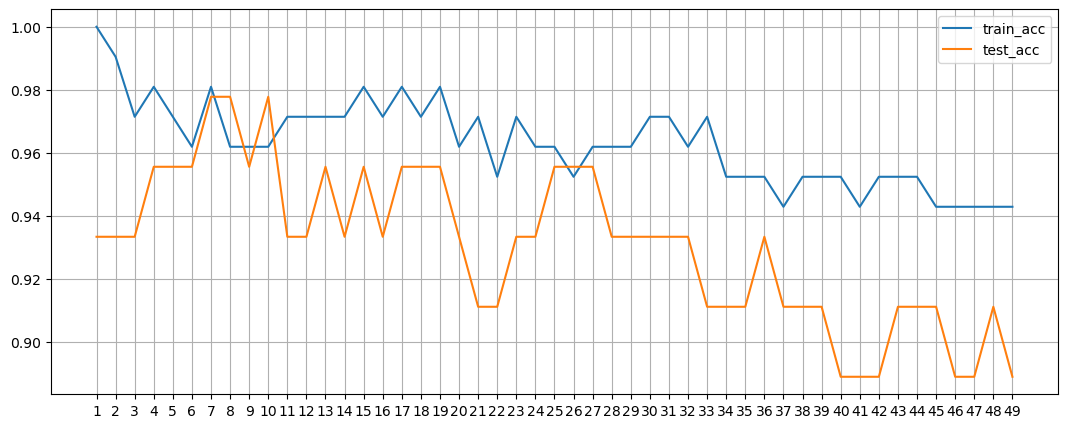

In [ ]:
plt.figure(figsize=(13,5))

plt.plot(range(1, 50, 1), train_list, label = 'train_acc')
plt.plot(range(1, 50, 1), test_list, label = 'test_acc')

plt.legend() # 범례

plt.grid() # 눈금선
plt.xticks(range(1, 50, 1))

plt.show()


## Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train.iloc[0].values)
print(X_train_scaled[0].round(3))

[5.  3.3 1.4 0.2]
[-1.023  0.538 -1.324 -1.311]


In [ ]:
# n_neighbors = 7

knn_raw = KNeighborsClassifier(n_neighbors = 7)
knn_raw.fit(X_train, y_train)
print(knn_raw.score(X_test, y_test))

knn_scaled = KNeighborsClassifier(n_neighbors = 7)
knn_scaled.fit(X_train_scaled, y_train)
print(knn_scaled.score(X_test_scaled, y_test))

0.9777777777777777
0.9555555555555556
